In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

# Previous Work

In [3]:
Data_PSH_Red = pd.read_csv("./PS-H_Red.csv")
Data_PSH_Yellow = pd.read_csv("./PS-H_Yellow.csv")
Data_PSH_Green = pd.read_csv("./PS-H_Green.csv")

Data_PSL_Red = pd.read_csv("./PS-L_Red.csv")
Data_PSL_Yellow = pd.read_csv("./PS-L_Yellow.csv")
Data_PSL_Green = pd.read_csv("./PS-L_Green.csv")

In [4]:
ColorsByMolecularMass = ["#9e2a2b","#e09f3e","#3a5a40","#9e2a2b","#e09f3e","#3a5a40","#9e2a2b","#e09f3e","#3a5a40","#9e2a2b","#e09f3e","#3a5a40"]

In [5]:
Data_PSH = pd.read_csv("./PS-H_Standard.csv")
Data_PSL = pd.read_csv("./PS-L_Standard.csv")

In [6]:
def ConvertPSH_rv_mp(RvValues):
    x = np.array(Data_PSH.rv)
    y = np.log(np.array(Data_PSH.Mp))
    # plt.scatter(x,y)

    coefficients = np.polyfit(x,y,3)
    p = np.poly1d(coefficients)
    xp = np.linspace(np.min(Data_PSH.rv),np.max(Data_PSH.rv),100)
    # plt.scatter(xp,p(xp))
    
    LoggedMpValues = p(RvValues)
    MpValues = np.exp(LoggedMpValues)
    return MpValues

In [7]:
PSHSomeRvValues = np.linspace(0,28,100)
PSHSomeMpValues = ConvertPSH_rv_mp(PSHSomeRvValues)

In [8]:
def AnXAxisCutter(LowerLimit,UpperLimit,Dataframe):
    StartIdx = 0
    EndIdx = len(Dataframe)-1
    LowerLimitIdx = 0
    UpperLimitIdx = 0
    for count,i in enumerate(Dataframe.rv):
        if i > LowerLimit:
            LowerLimitIdx = count
            break
    for count,i in enumerate(Dataframe.rv):
        if i > UpperLimit:
            UpperLimitIdx = count
            break
    FirstDropRange = np.linspace(StartIdx,LowerLimitIdx,(LowerLimitIdx-StartIdx)+1).astype(int).tolist()
    SecondDropRange = np.linspace(UpperLimitIdx,EndIdx,(EndIdx-UpperLimitIdx)+1).astype(int).tolist()
    NewDataframe = Dataframe.drop(FirstDropRange)
    NewestDataframe = NewDataframe.drop(SecondDropRange)
    return NewestDataframe

In [9]:
def RemoveBaseline(Baseline,RawData):
    ProcessedData = []
    for i in RawData:
        j = i-Baseline
        if j < 0:
            ProcessedDatum = 0
            ProcessedData.append(ProcessedDatum)
        else:
            ProcessedDatum = j
            ProcessedData.append(ProcessedDatum)
    return ProcessedData

In [10]:
Data_HMWR_PPSI = pd.read_csv("./HMWR_PPI.csv")
Data_HMWR_PPSI_CutOff = AnXAxisCutter(7.6,20.2,Data_HMWR_PPSI)

Baseline_HMWR_PPSI = np.array(Data_HMWR_PPSI_CutOff.ri)[-1]
Data_HMWR_PPSI_rv = Data_HMWR_PPSI_CutOff.rv
Data_HMWR_PPSI_ri = RemoveBaseline(Baseline_HMWR_PPSI,Data_HMWR_PPSI_CutOff.ri)
Data_HMWR_PPSI_mp = list(ConvertPSH_rv_mp(np.array(Data_HMWR_PPSI_CutOff.rv).tolist()))

In [11]:
Area_PPSI_ri = np.trapz(y=Data_HMWR_PPSI_ri,x=Data_HMWR_PPSI_rv,axis=-1)
Data_HMWR_PPSI_wf = []
Data_HMWR_PPSI_nwf = []
rv_last = 0
ri_last = 0
mw_last = 0
for count,(rv,ri,mw) in enumerate(zip(Data_HMWR_PPSI_rv,Data_HMWR_PPSI_ri,Data_HMWR_PPSI_mp)):
    rv_chng = abs(rv-rv_last)
    ri_chng = ri-ri_last
    if count == 0:
        rv_last = rv
        ri_last = ri
        mw_last = mw
        continue
    elif ri_chng<=0:
        area_sq = ri*rv_chng
        area_tri = (rv_chng*abs(ri-ri_last))/2
        area = area_sq-area_tri
        weightfraction = area/Area_PPSI_ri
        Data_HMWR_PPSI_wf.append(weightfraction)
        # mw_logchng = np.log(mw_last)-np.log(mw)
        mw_logchng = abs(np.log(mw)-np.log(mw_last))
        differntialDistribVal = weightfraction/mw_logchng
        Data_HMWR_PPSI_nwf.append(differntialDistribVal)
        rv_last = rv
        ri_last = ri
        mw_last = mw
        continue
    else:
        area_sq = ri*rv_chng
        area_tri = (rv_chng*abs(ri-ri_last))/2
        area = area_sq+area_tri
        weightfraction = area/Area_PPSI_ri
        Data_HMWR_PPSI_wf.append(weightfraction)
        # mw_logchng = np.log(mw_last)-np.log(mw)
        mw_logchng = abs(np.log(mw)-np.log(mw_last))
        differntialDistribVal = weightfraction/mw_logchng
        Data_HMWR_PPSI_nwf.append(differntialDistribVal)
        rv_last = rv
        ri_last = ri
        mw_last = mw
        continue

In [12]:
rv_last = 0
ri_last = 0
mp_last = 0
new_rv_lis = []
new_ri_lis = []
new_mp_lis = []
for count,(rv,ri,mp) in enumerate(zip(Data_HMWR_PPSI_rv,Data_HMWR_PPSI_ri,Data_HMWR_PPSI_mp)):
    if count == 0:
        rv_last = rv
        ri_last = ri
        mp_last = mp
        continue
    else:
        new_rv_lis.append((rv+rv_last)/2)
        new_ri_lis.append((ri+ri_last)/2)
        new_mp_lis.append((mp+mp_last)/2)
        rv_last = rv
        ri_last = ri
        mp_last = mp
Data_HMWR_PPSI_rv = new_rv_lis
Data_HMWR_PPSI_ri = new_ri_lis
Data_HMWR_PPSI_mp = new_mp_lis

# Modelling Explanation

In [13]:
ri = list(reversed(Data_HMWR_PPSI_ri))
mw = list(reversed(Data_HMWR_PPSI_mp))

# Curve A

(0.0, 57.732247360792876)

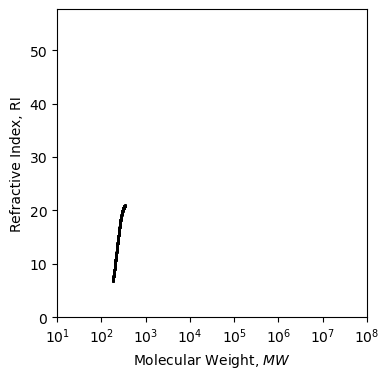

In [14]:
# Curve Isolation
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.scatter(mw[800:1400],ri[800:1400],color="black",s=1)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,100000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
ax1.set_ylim(0,np.max(ri)*1.05)

In [15]:
# Curve Model
def f(x,*params):
    a_1,sigma_1,mu_1 = params[0],params[1],params[2]
    return a_1*(1.0/(x*sigma_1*np.sqrt(2*np.pi))*np.exp(-(np.log(x)-mu_1)**2/(2.0*sigma_1**2)))

In [16]:
a_1 = 5.03950566212667
sigma_1 = 0.171895767644522
mu_1 = 5.72589898695787
f_popt,f_pcov = sp.optimize.curve_fit(f=f,xdata=mw[800:1400],ydata=ri[800:1400],p0=[a_1,sigma_1,mu_1])

(0.0, 57.732247360792876)

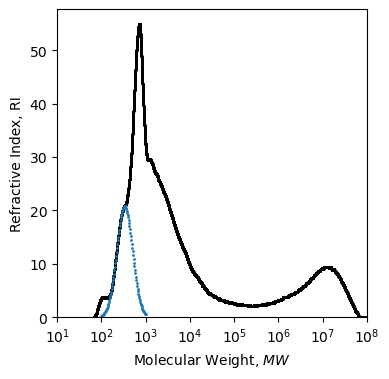

In [17]:
# TrialSamples
fTrialXs = np.logspace(start=2,stop=3,num=100)
fTrialYs = []
for n in fTrialXs:
    fTrialYs.append(f(n,f_popt[0],f_popt[1],f_popt[2]))
# PPI
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.scatter(mw,ri,color="black",s=1)
ax1.scatter(fTrialXs,fTrialYs,s=1)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,100000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
ax1.set_ylim(0,np.max(ri)*1.05)

# Curve B

(0.0, 57.732247360792876)

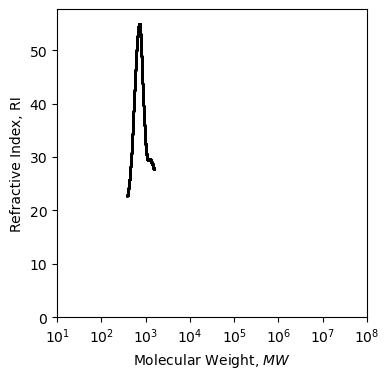

In [18]:
# Curve Isolation
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.scatter(mw[1500:3000],ri[1500:3000],color="black",s=1)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,100000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
ax1.set_ylim(0,np.max(ri)*1.05)

In [19]:
# Curve Model
def g(x,*params):
    a_2,sigma_2,mu_2 = params[0],params[1],params[2]
    return a_2*(1.0/(x*sigma_2*np.sqrt(2*np.pi))*np.exp(-(np.log(x)-mu_2)**2/(2.0*sigma_2**2)))

In [20]:
a_2 = 109.978571665277
sigma_2 = 0.230957737603889
mu_2 = 6.53661650427705
g_popt,g_pcov = sp.optimize.curve_fit(f=g,xdata=mw[1500:3000],ydata=ri[1500:3000],p0=[a_2,sigma_2,mu_2])

(0.0, 57.732247360792876)

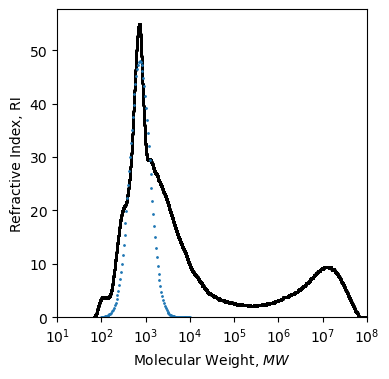

In [21]:
# TrialSamples
gTrialXs = np.logspace(start=2,stop=4,num=100)
gTrialYs = []
for n in gTrialXs:
    gTrialYs.append(g(n,g_popt[0],g_popt[1],g_popt[2]))
# PPI
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.scatter(mw,ri,color="black",s=1)
ax1.scatter(gTrialXs,gTrialYs,s=1)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,100000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
ax1.set_ylim(0,np.max(ri)*1.05)

# Curve C

(0.0, 57.732247360792876)

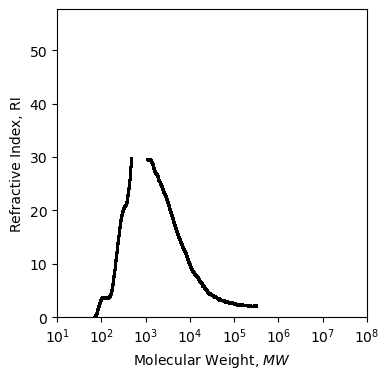

In [22]:
# Curve Isolation
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.scatter(mw[0:1700],ri[0:1700],color="black",s=1)
ax1.scatter(mw[2600:9000],ri[2600:9000],color="black",s=1)
ax1.scatter(mw[0:1700]+mw[2600:9000],ri[0:1700]+ri[2600:9000],color="black",s=1)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,100000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
ax1.set_ylim(0,np.max(ri)*1.05)

In [23]:
# Curve Model
def h(x,*params):
    a_3,sigma_3,mu_3 = params[0],params[1],params[2]
    return a_3*(1.0/(x*sigma_3*np.sqrt(2*np.pi))*np.exp(-(np.log(x)-mu_3)**2/(2.0*sigma_3**2)))

In [24]:
# Fitting
a_3 = 9110.46065737538
sigma_3 = 1.50187563742626
mu_3 = 9.87858247573214
h_popt,h_pcov = sp.optimize.curve_fit(f=h,xdata=mw[0:1700]+mw[2600:9000],ydata=ri[0:1700]+ri[2600:9000],p0=[a_3,sigma_3,mu_3])

(0.0, 57.732247360792876)

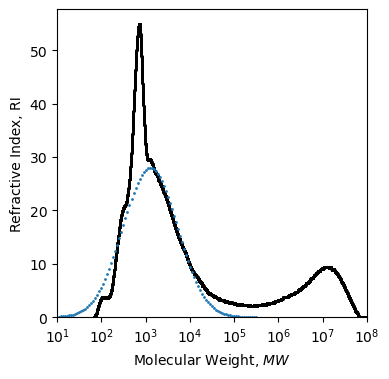

In [25]:
# TrialSamples
hTrialXs = np.logspace(start=1,stop=5.5,num=100)
hTrialYs = []
for n in hTrialXs:
    hTrialYs.append(h(n,h_popt[0],h_popt[1],h_popt[2]))
# PPI
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.scatter(mw,ri,color="black",s=1)
ax1.scatter(hTrialXs,hTrialYs,s=1)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,100000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
ax1.set_ylim(0,np.max(ri)*1.05)

# Curves A, B, & C

(0.0, 57.732247360792876)

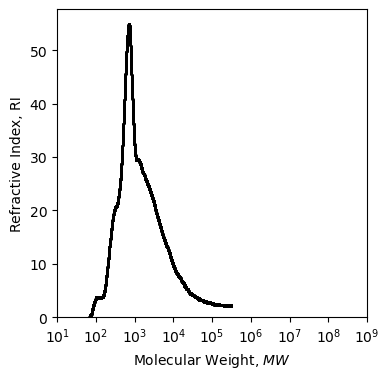

In [26]:
# Curve Isolation
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.scatter(mw[0:9000],ri[0:9000],color="black",s=1)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,1000000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000,1000000000])
ax1.set_ylim(0,np.max(ri)*1.05)

In [27]:
def i(x,*params):
    a = f(x,params[0],params[1],params[2])
    b = g(x,params[3],params[4],params[5])
    c = h(x,params[6],params[7],params[8])
    return a+b+c

In [28]:
a_1 = f_popt[0]
sigma_1 = f_popt[1]
mu_1 = f_popt[2]

a_2 = g_popt[0]
sigma_2 = g_popt[1]
mu_2 = g_popt[2]

a_3 = h_popt[0]
sigma_3 = h_popt[1]
mu_3 = h_popt[2]

i_popt,i_pcov = sp.optimize.curve_fit(f=i,xdata=mw[0:9000],ydata=ri[0:9000],p0=[a_1,sigma_1,mu_1,a_2,sigma_2,mu_2,a_3,sigma_3,mu_3],maxfev=2000)

(0.0, 57.732247360792876)

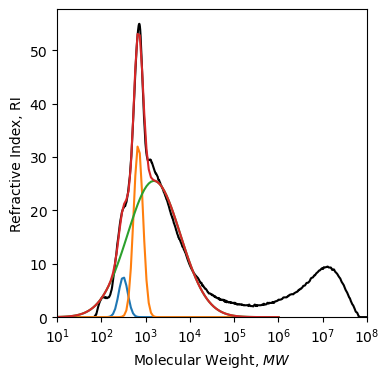

In [29]:
# TrialSamples
FinalTrialXs = np.logspace(start=1,stop=6,num=100)

FinalfTrialYs = []
for n in FinalTrialXs:
    FinalfTrialYs.append(f(n,i_popt[0],i_popt[1],i_popt[2]))

FinalgTrialYs = []
for n in FinalTrialXs:
    FinalgTrialYs.append(g(n,i_popt[3],i_popt[4],i_popt[5]))

FinalhTrialYs = []
for n in FinalTrialXs:
    FinalhTrialYs.append(h(n,i_popt[6],i_popt[7],i_popt[8]))

FinaliTrialYs = []
for n in FinalTrialXs:
    FinaliTrialYs.append(i(n,i_popt[0],i_popt[1],i_popt[2],i_popt[3],i_popt[4],i_popt[5],i_popt[6],i_popt[7],i_popt[8]))

# PPI
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.plot(mw,ri,color="black")
ax1.plot(FinalTrialXs,FinalfTrialYs)
ax1.plot(FinalTrialXs,FinalgTrialYs)
ax1.plot(FinalTrialXs,FinalhTrialYs)
ax1.plot(FinalTrialXs,FinaliTrialYs)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,100000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
ax1.set_ylim(0,np.max(ri)*1.05)

# Combined Plots

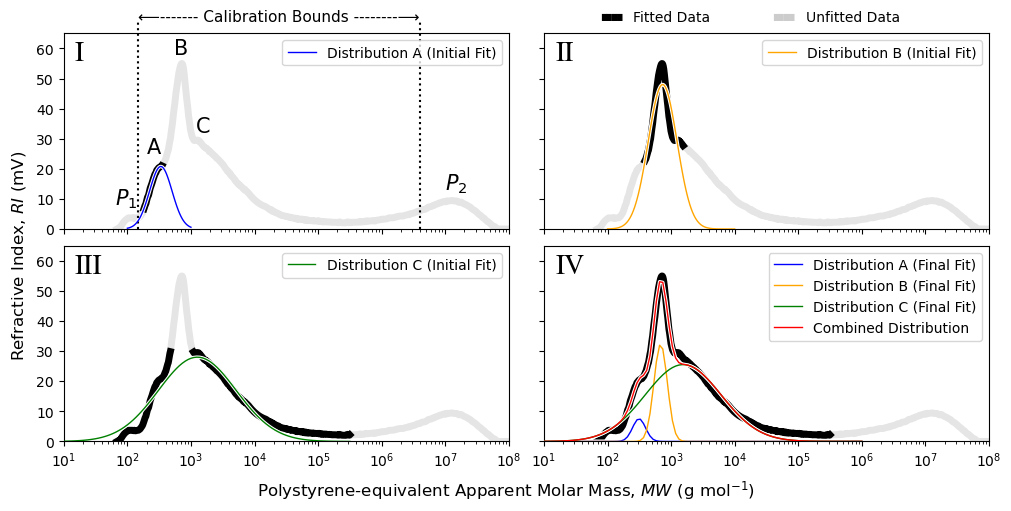

In [30]:
gs_kw = dict(width_ratios=[1, 1],height_ratios=[1,1])
fig, axd = plt.subplot_mosaic([['upL', 'upR'],
                               ['loL', 'loR']],
                              gridspec_kw=gs_kw, figsize=(10,5),
                              layout="constrained")

# Fitted Material - Distribution A
axd["upL"].plot(mw[0:800],ri[0:800],color="black",linewidth=5,zorder=1,alpha=0.1)
axd["upL"].plot(mw[800:1400],ri[800:1400],color="black",linewidth=5,zorder=1)
axd["upL"].plot(mw[1400:12598],ri[1400:12598],color="black",linewidth=5,zorder=1,alpha=0.1)
# Fitted Material - Distribution B
axd["upR"].plot(mw[0:1500],ri[0:1500],color="black",linewidth=5,zorder=1,alpha=0.1)
axd["upR"].plot(mw[1500:3000],ri[1500:3000],color="black",linewidth=5,zorder=1)
axd["upR"].plot(mw[3000:12598],ri[3000:12598],color="black",linewidth=5,zorder=1,alpha=0.1)
# Fitted Material - Distribution C
axd["loL"].plot(mw[0:1700],ri[0:1700],color="black",linewidth=5,zorder=1)
axd["loL"].plot(mw[1700:2600],ri[1700:2600],color="black",linewidth=5,zorder=1,alpha=0.1)
axd["loL"].plot(mw[2600:9000],ri[2600:9000],color="black",linewidth=5,zorder=1)
axd["loL"].plot(mw[9000:12598],ri[9000:12598],color="black",linewidth=5,zorder=1,alpha=0.1)
# Fitted Material - Entire Distribution
axd["loR"].plot(mw[0:9000],ri[0:9000],color="black",linewidth=5,zorder=1)
axd["loR"].plot(mw[9000:12598],ri[9000:12598],color="black",linewidth=5,zorder=1,alpha=0.1)

# Fitted Distribution - A
axd["upL"].plot(fTrialXs,fTrialYs,color="white",linewidth=2.5,zorder=2)
axd["upL"].plot(fTrialXs,fTrialYs,color="blue",linewidth=1,zorder=3,label="Distribution A (Initial Fit)")
# Fitted Distribution - B
axd["upR"].plot(gTrialXs,gTrialYs,color="white",linewidth=2.5,zorder=2)
axd["upR"].plot(gTrialXs,gTrialYs,color="orange",linewidth=1,zorder=3,label="Distribution B (Initial Fit)")
# Fitted Distribution - C
axd["loL"].plot(hTrialXs,hTrialYs,color="white",linewidth=2.5,zorder=2)
axd["loL"].plot(hTrialXs,hTrialYs,color="green",linewidth=1,zorder=3,label="Distribution C (Initial Fit)")
# Fitted Distribution - All
axd["loR"].plot(FinalTrialXs,FinalfTrialYs,color="white",linewidth=2.5,zorder=2)
axd["loR"].plot(FinalTrialXs,FinalfTrialYs,color="blue",linewidth=1,zorder=3,label="Distribution A (Final Fit)")
axd["loR"].plot(FinalTrialXs,FinalgTrialYs,color="white",linewidth=2.5,zorder=2)
axd["loR"].plot(FinalTrialXs,FinalgTrialYs,color="orange",linewidth=1,zorder=3,label="Distribution B (Final Fit)")
axd["loR"].plot(FinalTrialXs,FinalhTrialYs,color="white",linewidth=2.5,zorder=2)
axd["loR"].plot(FinalTrialXs,FinalhTrialYs,color="green",linewidth=1,zorder=3,label="Distribution C (Final Fit)")
axd["loR"].plot(FinalTrialXs,FinaliTrialYs,color="white",linewidth=2.5,zorder=2)
axd["loR"].plot(FinalTrialXs,FinaliTrialYs,color="red",linewidth=1,zorder=3,label="Combined Distribution")

# Axes Setup - Distribution A
axd["upL"].set_xscale('log')
axd["upL"].set_xlim(10,100000000)
axd["upL"].set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
axd["upL"].set_xticklabels([])
axd["upL"].set_ylim(0,65)
# Axes Setup - Distribution B
axd["upR"].set_xscale('log')
axd["upR"].set_xlim(10,100000000)
axd["upR"].set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
axd["upR"].set_xticklabels([])
axd["upR"].set_ylim(0,65)
axd["upR"].set_yticklabels([])
# Axes Setup - Distribution C
axd["loL"].set_xscale('log')
axd["loL"].set_xlim(10,100000000)
axd["loL"].set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
axd["loL"].set_ylim(0,65)
# Axes Setup - Entire Distribution
axd["loR"].set_xscale('log')
axd["loR"].set_xlim(10,100000000)
axd["loR"].set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
axd["loR"].set_ylim(0,65)
axd["loR"].set_yticklabels([])

fig.supylabel(r"Refractive Index, $RI$ (mV)")
fig.supxlabel(r'Polystyrene-equivalent Apparent Molar Mass, $MW$ (g mol$^{-1}$)')

axd["upL"].legend()
axd["upR"].legend()
axd["loL"].legend()
axd["loR"].legend()

axd["upR"].text(x=80,y=65+5,s="████",fontsize=5)
axd["upR"].text(x=250,y=64+5,s="Fitted Data",fontsize=10)

axd["upR"].text(x=40000,y=65+5,s="████",fontsize=5,alpha=0.2)
axd["upR"].text(x=130000,y=64+5,s="Unfitted Data",fontsize=10)

axd["upL"].text(x=15,y=51+5,s="I",fontsize=20,font='times')
axd["upR"].text(x=15,y=51+5,s="II",fontsize=20,font='times')
axd["loL"].text(x=15,y=51+5,s="III",fontsize=20,font='times')
axd["loR"].text(x=15,y=51+5,s="IV",fontsize=20,font='times')

axd["upL"].text(x=200,y=25,s="A",fontsize=15)
axd["upL"].text(x=550,y=58,s="B",fontsize=15)
axd["upL"].text(x=1200,y=32,s="C",fontsize=15)
axd["upL"].text(x=65,y=8,s=r"$P_{1}$",fontsize=15)
axd["upL"].text(x=10000000,y=13,s=r"$P_{2}$",fontsize=15)

axd["upL"].axvline(ymin=0,ymax=1.07,x=3981096.24461375,linestyle="dotted",color="black").set_clip_on(False)
axd["upL"].axvline(ymin=0,ymax=1.07,x=144.54622191,linestyle="dotted",color="black").set_clip_on(False)
axd["upL"].text(148,69,"⟵------- Calibration Bounds --------⟶",fontsize=11)

plt.savefig(fname='GPCDistribExplain.png',bbox_inches="tight",dpi=1000,format='png')

In [104]:
# Fitted Distribution - A
AreaA = np.trapz(x=fTrialXs,y=fTrialYs,dx=0.01)
# Fitted Distribution - B
AreaB = np.trapz(x=gTrialXs,y=gTrialYs,dx=0.01)
# Fitted Distribution - C
AreaC = np.trapz(x=hTrialXs,y=hTrialYs,dx=0.01)
# Combined Distribution - D
AreaD = np.trapz(x=FinalTrialXs,y=FinaliTrialYs,dx=0.01)
# Combined Area
AreaE = AreaA+AreaB+AreaC

In [105]:
print(round(AreaA/AreaD*100,2))
print(round(AreaB/AreaD*100,2))
print(round(AreaC/AreaD*100,2))
print(round(AreaD/AreaD*100,2))

2.1
14.53
91.26
100.0


In [ ]:
print(round(AreaA/AreaE*100,2))
print(round(AreaB/AreaE*100,2))
print(round(AreaC/AreaE*100,2))
print(round(AreaE/AreaE*100,2))

1.95
13.47
84.58
100.0
